In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv('../Dataset/vehicles.csv')
print(f"Cantidad de filas: {df.shape[0]:,}  -  Cantidad de columnas: {df.shape[1]}")

Cantidad de filas: 426,880  -  Cantidad de columnas: 26


In [ ]:
# Tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [8]:
# Inspección inicial de los datos

df.head(150)

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,7304134738,https://auburn.craigslist.org/ctd/d/auburn-uni...,auburn,https://auburn.craigslist.org,31590,2017.0,jeep,wrangler unlimited sport,good,6 cylinders,...,NaN,SUV,black,https://images.craigslist.org/00W0W_buOjh5s1Qh...,Carvana is the safer way to buy a car During t...,NaN,al,32.59,-85.48,2021-04-09T09:31:05-0500
146,7304111898,https://auburn.craigslist.org/ctd/d/auburn-uni...,auburn,https://auburn.craigslist.org,30990,2017.0,jeep,wrangler unlimited sport,good,6 cylinders,...,NaN,SUV,silver,https://images.craigslist.org/00j0j_BfPLW19l2F...,Carvana is the safer way to buy a car During t...,NaN,al,32.59,-85.48,2021-04-09T08:51:07-0500
147,7303661415,https://auburn.craigslist.org/ctd/d/auburn-uni...,auburn,https://auburn.craigslist.org,14590,2012.0,bmw,1 series 128i coupe 2d,good,NaN,...,NaN,coupe,black,https://images.craigslist.org/00F0F_5UAXmOzC18...,Carvana is the safer way to buy a car During t...,NaN,al,32.59,-85.48,2021-04-08T10:41:14-0500
148,7303661350,https://auburn.craigslist.org/ctd/d/auburn-uni...,auburn,https://auburn.craigslist.org,20590,2018.0,chrysler,300 limited sedan 4d,good,6 cylinders,...,NaN,sedan,black,https://images.craigslist.org/00x0x_ga6n3ZpljY...,Carvana is the safer way to buy a car During t...,NaN,al,32.59,-85.48,2021-04-08T10:41:10-0500


In [9]:
# Estadísticas descriptivas

df.describe()

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


Filas eliminadas por precio (Outliers/Ruido): 42,749


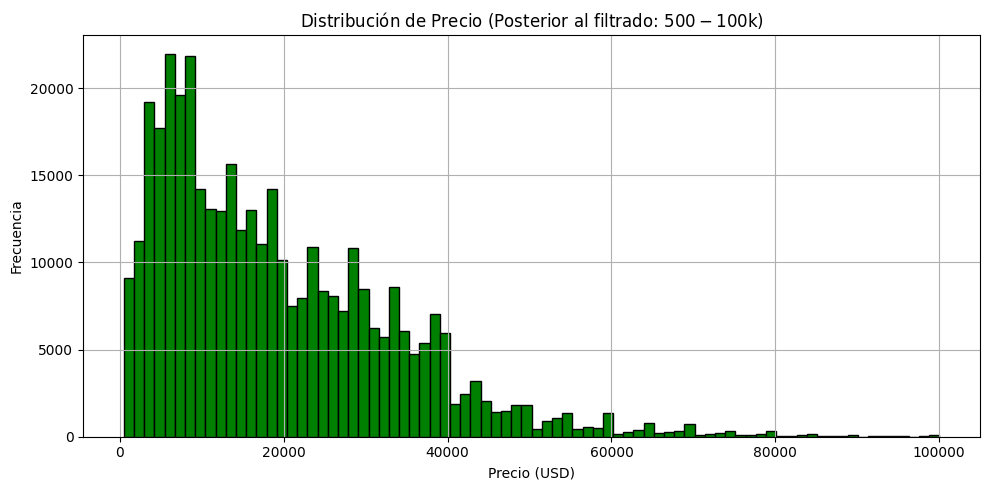

In [ ]:
# Distribución de variables numéricas

# Price
# Filtrar el precio entre $500 y $100,000 (rango comercial lógico)
df_precio = df[(df['price'] >= 500) & (df['price'] <= 100000)].copy()
print(f"Filas eliminadas por precio (Outliers/Ruido): {len(df) - len(df_precio):,}")

plt.figure(figsize=(10, 5))
df_precio['price'].hist(bins=80, color='green', edgecolor='black')
plt.title('Distribución de Precio (Posterior al filtrado: $500 - $100k)')
plt.xlabel('Precio (USD)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('precio_distribucion.png', dpi=150)
plt.show()


Filas eliminadas por año (Antiguos/Errores): 13,588


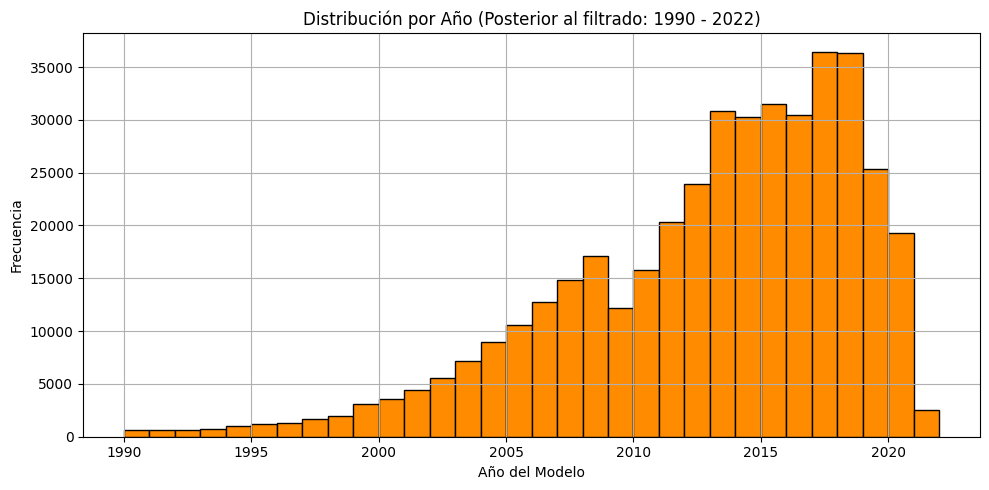

In [7]:
# Distribución de variables numéricas

# Year
# Filtrar años entre 1990 y 2022
df_year = df[(df['year'] >= 1990) & (df['year'] <= 2022)].copy()
print(f"Filas eliminadas por año (Antiguos/Errores): {len(df) - len(df_year):,}")

plt.figure(figsize=(10, 5))
df_year['year'].hist(bins=32, color='darkorange', edgecolor='black')
plt.title('Distribución por Año (Posterior al filtrado: 1990 - 2022)')
plt.xlabel('Año del Modelo')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('year_distribucion.png', dpi=150)
plt.show()

Filas eliminadas por kilometraje (Outliers/Inconsistencias): 13,594


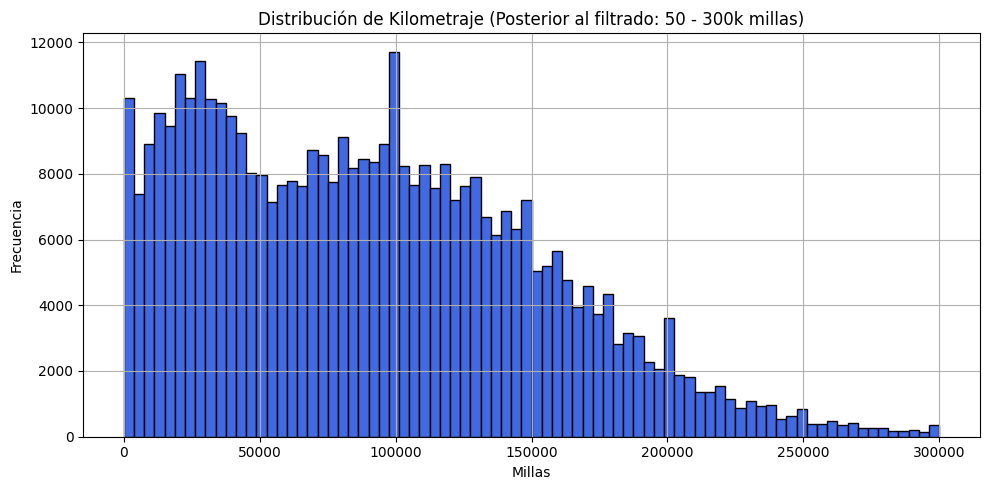

In [9]:
# Distribución de variables numéricas

# Odometer
# Filtrar kilometraje entre 50 y 300,000 millas
df_odo = df[(df['odometer'] >= 50) & (df['odometer'] <= 300000)].copy()
print(f"Filas eliminadas por kilometraje (Outliers/Inconsistencias): {len(df) - len(df_odo):,}")

plt.figure(figsize=(10, 5))
df_odo['odometer'].hist(bins=80, color='royalblue', edgecolor='black')
plt.title('Distribución de Kilometraje (Posterior al filtrado: 50 - 300k millas)')
plt.xlabel('Millas')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('odometer_distribucion.png', dpi=150)
plt.show()

C:\Users\andy2\AppData\Local\Temp\ipykernel_5812\1423001895.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_fabricantes.values, y=top_fabricantes.index, palette='Paired')


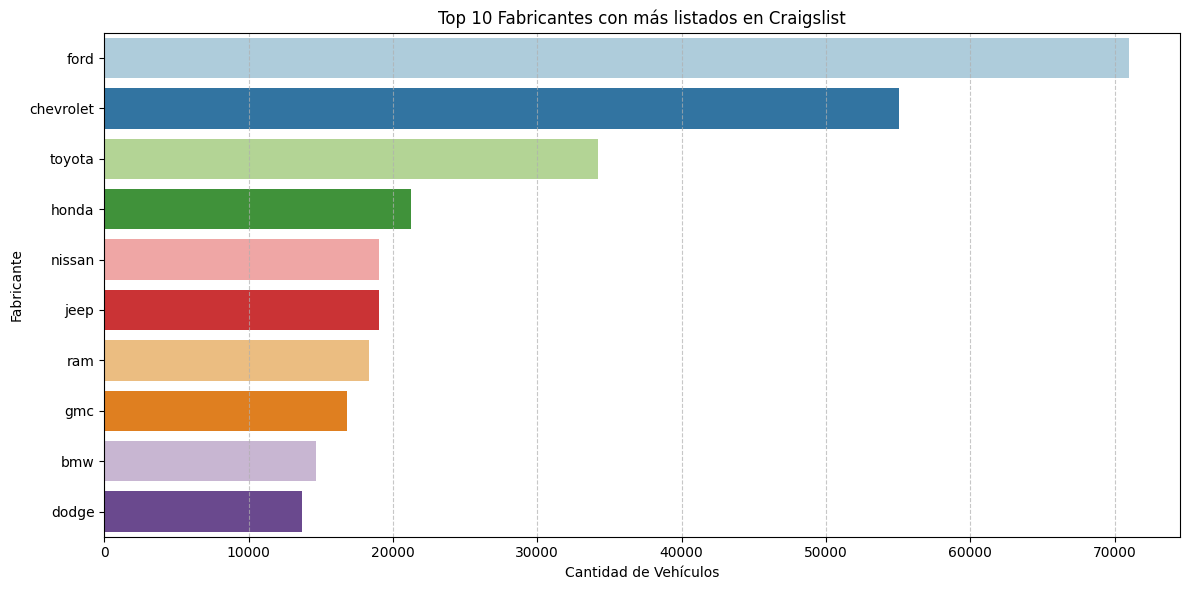

El fabricante líder es: FORD con 70,985 anuncios.


In [12]:
# Distribución de variables categóricas

# Top de Fabricantes
# Conteo de vehículos por fabricante
top_fabricantes = df['manufacturer'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_fabricantes.values, y=top_fabricantes.index, palette='Paired')

plt.title('Top 10 Fabricantes con más listados en Craigslist')
plt.xlabel('Cantidad de Vehículos')
plt.ylabel('Fabricante')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('top_fabricantes.png', dpi=150)
plt.show()

print(f"El fabricante líder es: {top_fabricantes.index[0].upper()} con {top_fabricantes.values[0]:,} anuncios.")

C:\Users\andy2\AppData\Local\Temp\ipykernel_5812\2939998914.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='fuel', order=fuel_counts.index, palette='Paired')


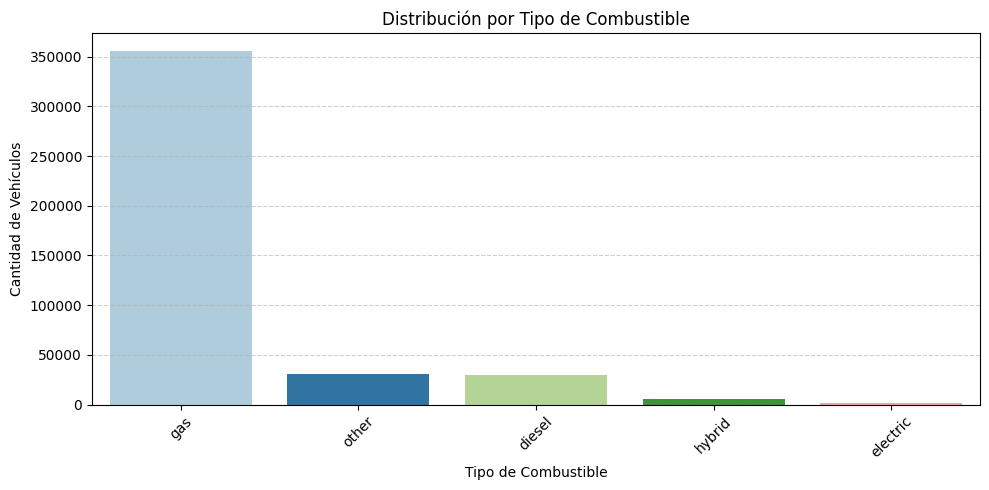


Distribución porcentual:
fuel
gas         84.037918
other        7.249444
diesel       7.092319
hybrid       1.219722
electric     0.400597
Name: proportion, dtype: float64


In [18]:
# Distribución de variables categóricas

# Tipos de combustible
# Conteo de tipos de combustible (eliminando nulos para la visualización)
fuel_counts = df['fuel'].value_counts()

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='fuel', order=fuel_counts.index, palette='Paired')

plt.title('Distribución por Tipo de Combustible')
plt.xlabel('Tipo de Combustible')
plt.ylabel('Cantidad de Vehículos')
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('tipo_combustible.png', dpi=150)
plt.show()

# Mostrar porcentajes rápidos
print("\nDistribución porcentual:")
print(df['fuel'].value_counts(normalize=True) * 100)

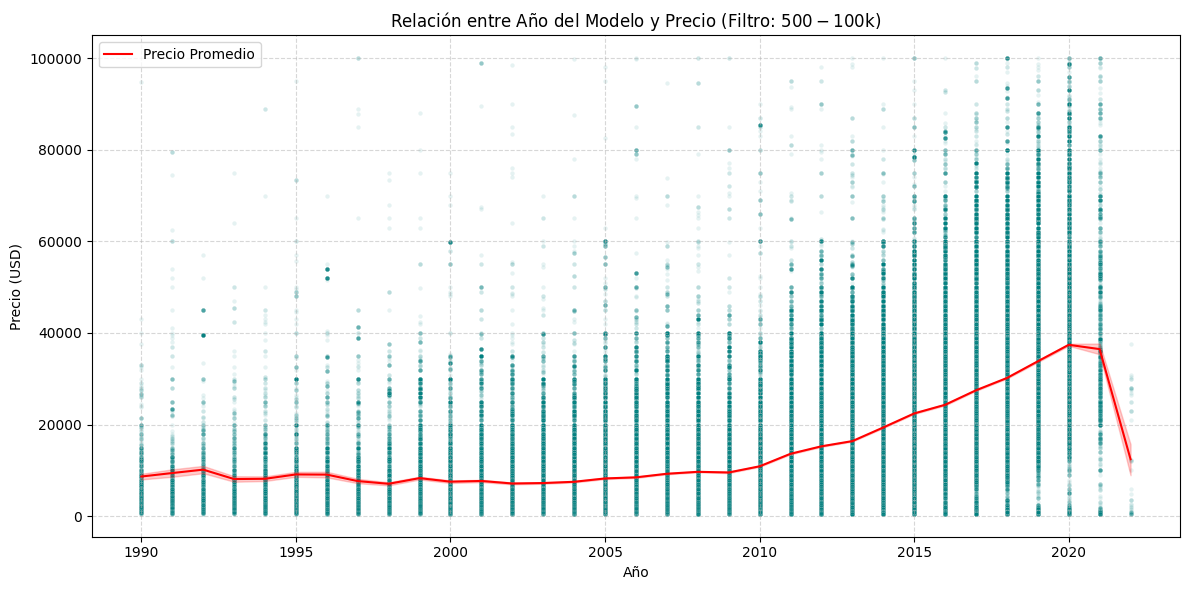

In [2]:
# Relaciones entre variables

# Precio vs Year

# Se usa el dataset filtrado
df_relacion = df[(df['price'] >= 500) & (df['price'] <= 100000) & 
                 (df['year'] >= 1990) & (df['year'] <= 2022)].copy()

plt.figure(figsize=(12, 6))

sns.scatterplot(data=df_relacion, x='year', y='price', alpha=0.1, color='teal', s=10)
sns.lineplot(data=df_relacion, x='year', y='price', color='red', label='Precio Promedio')

plt.title('Relación entre Año del Modelo y Precio (Filtro: $500 - $100k)')
plt.xlabel('Año')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('precio_vs_año.png', dpi=150)
plt.show()

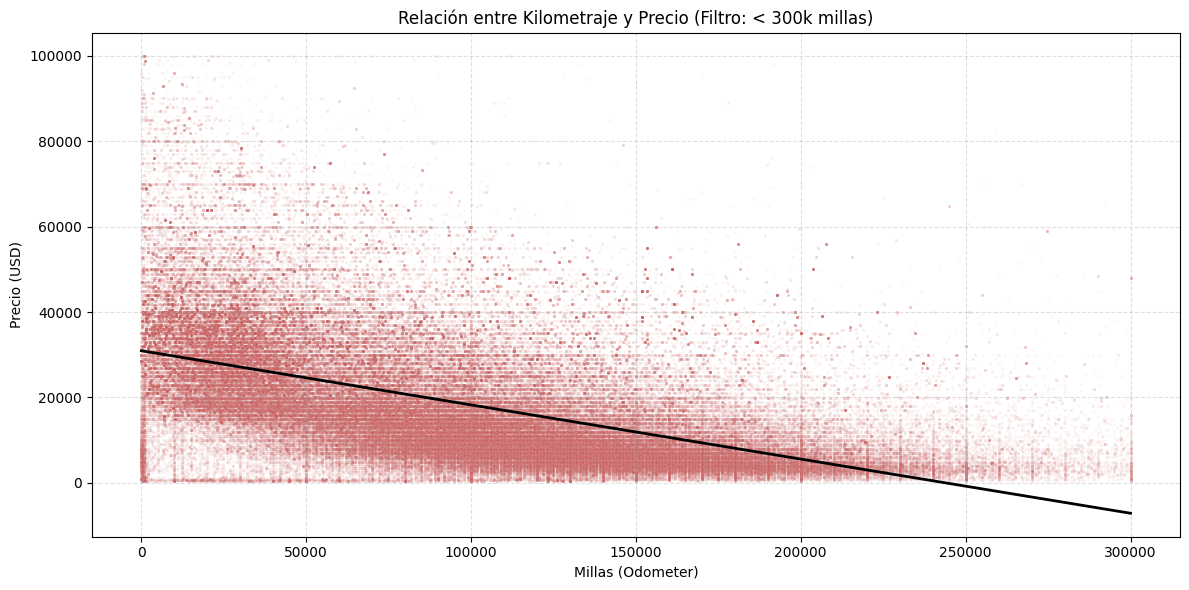

In [3]:
# Relaciones entre variables

# Precio vs Kilometraje

# Se usa el dataset filtrado
df_odo_price = df[(df['price'] >= 500) & (df['price'] <= 100000) & 
                  (df['odometer'] >= 100) & (df['odometer'] <= 300000)].copy()

plt.figure(figsize=(12, 6))

sns.scatterplot(data=df_odo_price, x='odometer', y='price', alpha=0.05, color='indianred', s=5)
sns.regplot(data=df_odo_price, x='odometer', y='price', scatter=False, color='black', line_kws={"linewidth":2})

plt.title('Relación entre Kilometraje y Precio (Filtro: < 300k millas)')
plt.xlabel('Millas (Odometer)')
plt.ylabel('Precio (USD)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('precio_vs_odometer.png', dpi=150)
plt.show()

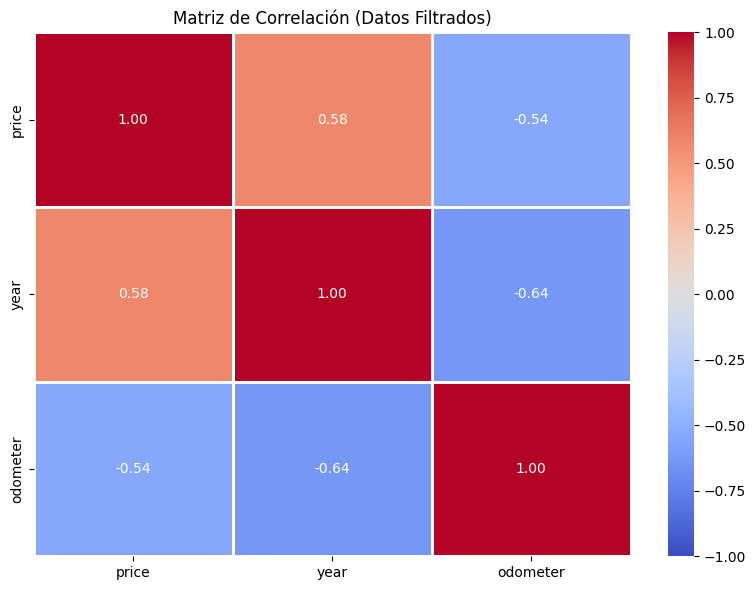

In [7]:
# Correlación entre variables

# Dataset filtrado 
df_limpio = df[
    (df['price'].between(500, 100000)) & 
    (df['year'].between(1990, 2022)) & 
    (df['odometer'].between(100, 500000))
].copy()

# Solo se usan las columnas: price, year y odometer
columnas = ['price', 'year', 'odometer']
matriz_corr = df_limpio[columnas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, 
            annot=True, 
            fmt=".2f", # 2 decimales
            cmap='coolwarm', # Azul para negativo, Rojo para positivo
            linewidths=2,
            vmin=-1, vmax=1) # de -1 a 1

plt.title('Matriz de Correlación (Datos Filtrados)')
plt.tight_layout()
plt.savefig('matriz_correlacion.png', dpi=150)
plt.show()

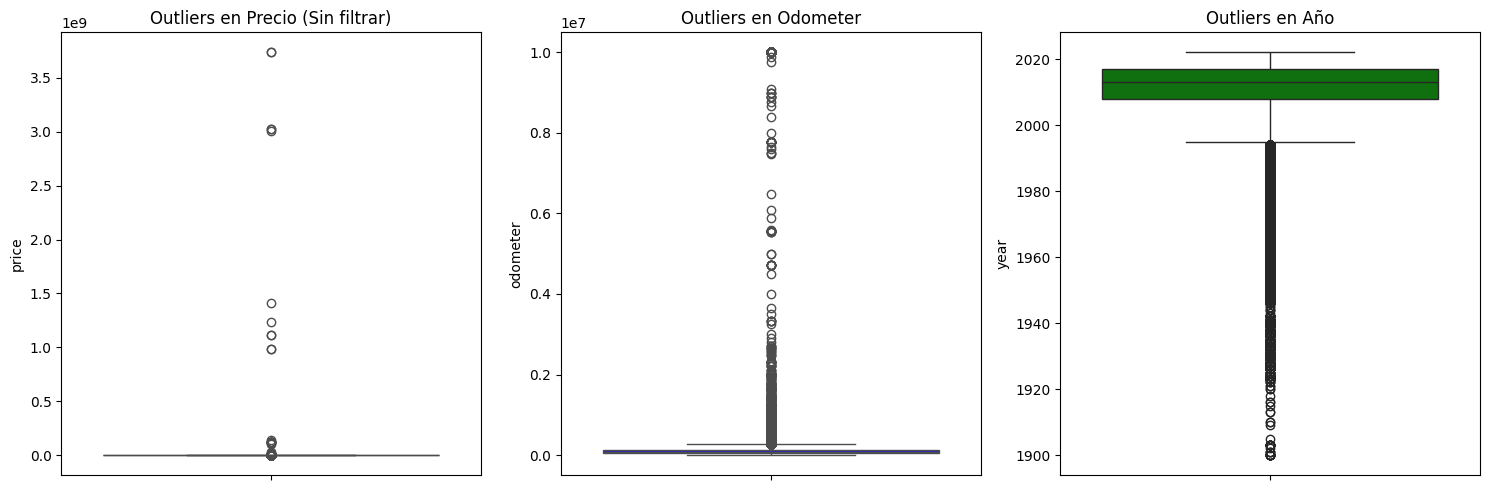

In [8]:
# Detección de Outliers

plt.figure(figsize=(15, 5))

# Boxplot para Precio
plt.subplot(1, 3, 1)
sns.boxplot(y=df['price'], color='red')
plt.title('Outliers en Precio (Sin filtrar)')

# Boxplot para Odometer
plt.subplot(1, 3, 2)
sns.boxplot(y=df['odometer'], color='blue')
plt.title('Outliers en Odometer')

# Boxplot para Year
plt.subplot(1, 3, 3)
sns.boxplot(y=df['year'], color='green')
plt.title('Outliers en Año')

plt.tight_layout()
plt.savefig('deteccion_outliers_inicial.png', dpi=150, bbox_inches='tight')
plt.show()

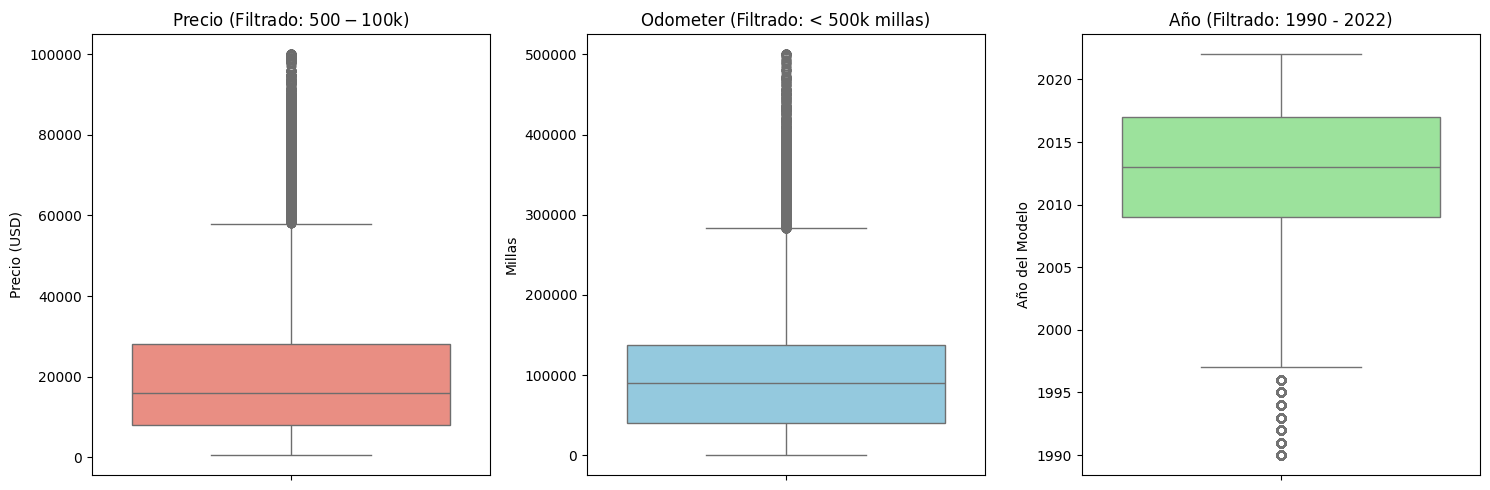

In [10]:
# Detección de Outliers

# Con el Dataset filtrado
# Price ($500-$100k), Year (1990-2022) y Odometer (100-500k)

plt.figure(figsize=(15, 5))

# Boxplot para Precio (Limpio)
plt.subplot(1, 3, 1)
sns.boxplot(y=df_limpio['price'], color='salmon')
plt.title('Precio (Filtrado: $500 - $100k)')
plt.ylabel('Precio (USD)')

# Boxplot para Odometer (Limpio)
plt.subplot(1, 3, 2)
sns.boxplot(y=df_limpio['odometer'], color='skyblue')
plt.title('Odometer (Filtrado: < 500k millas)')
plt.ylabel('Millas')

# Boxplot para Year (Limpio)
plt.subplot(1, 3, 3)
sns.boxplot(y=df_limpio['year'], color='lightgreen')
plt.title('Año (Filtrado: 1990 - 2022)')
plt.ylabel('Año del Modelo')


plt.tight_layout()
plt.savefig('boxplots_datos_filtrados.png', dpi=150, bbox_inches='tight')
plt.show()